# **Import Library & Load Data**

In [1]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
from collections import Counter

In [2]:
# =============================
# LOAD DATA
# =============================
file_path = r"G:\5. PT Raecca Kreasi Indonesia\7. Data Kompetitor\Data Video Raecca dan Competitor.xlsx"
df = pd.read_excel(file_path)

# =============================
# TEXT CLEANING
# =============================
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-z0-9\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df["clean_caption"] = df["Caption"].apply(clean_text)

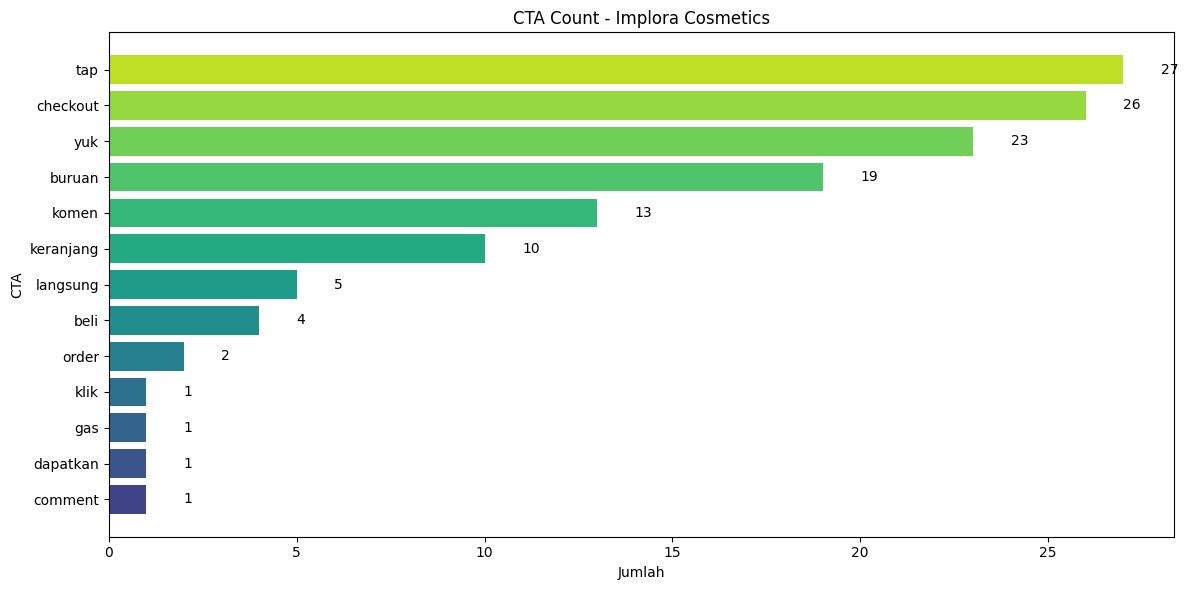

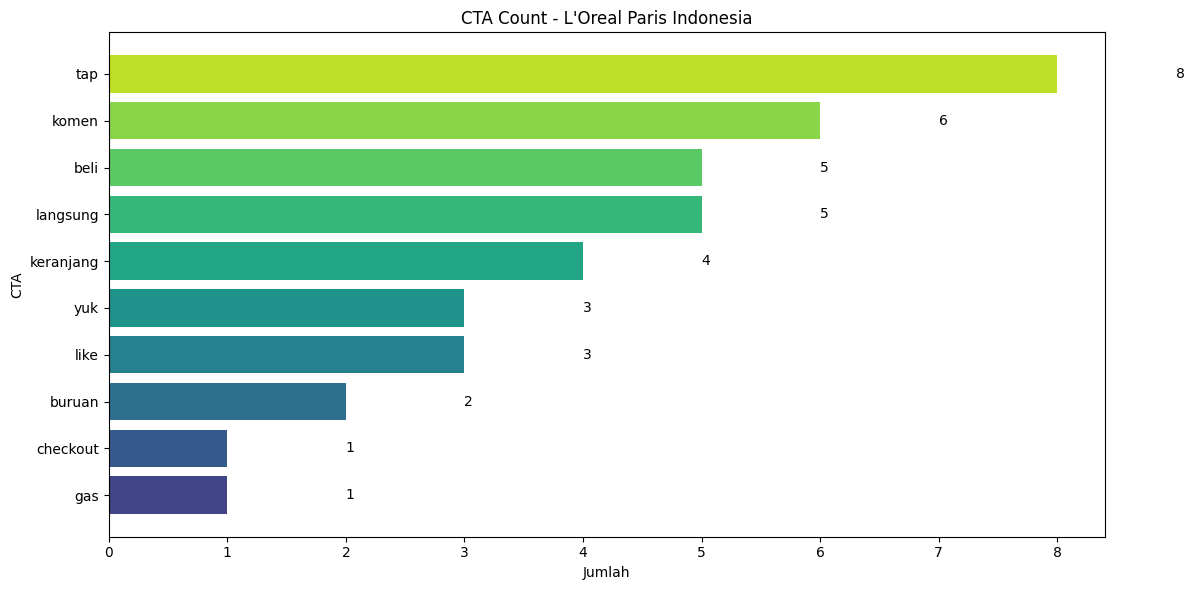

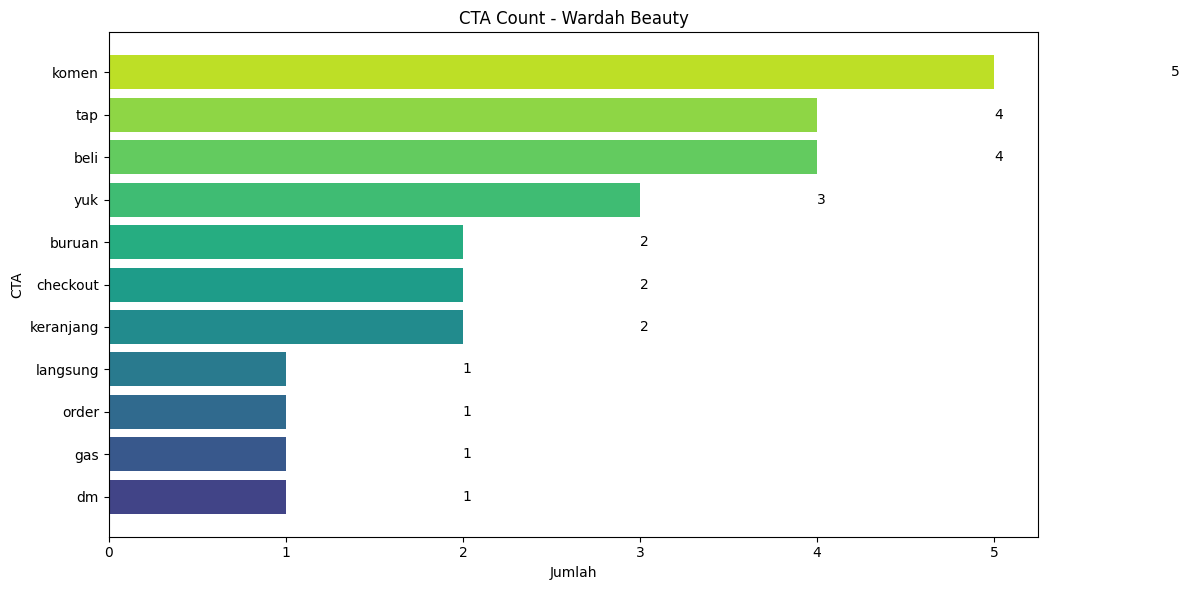

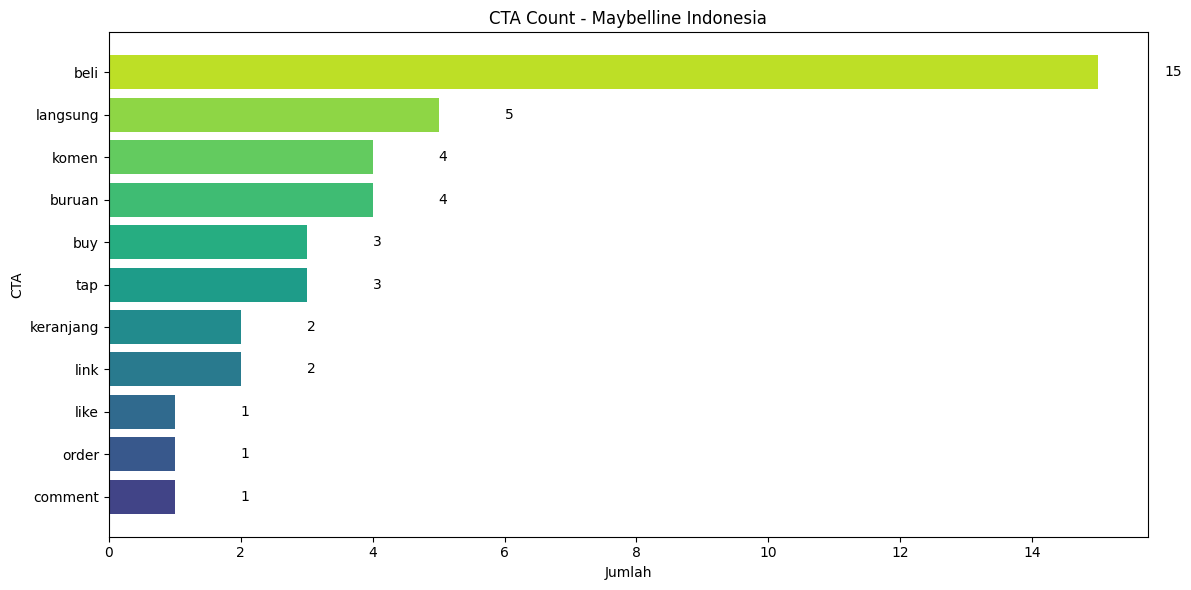

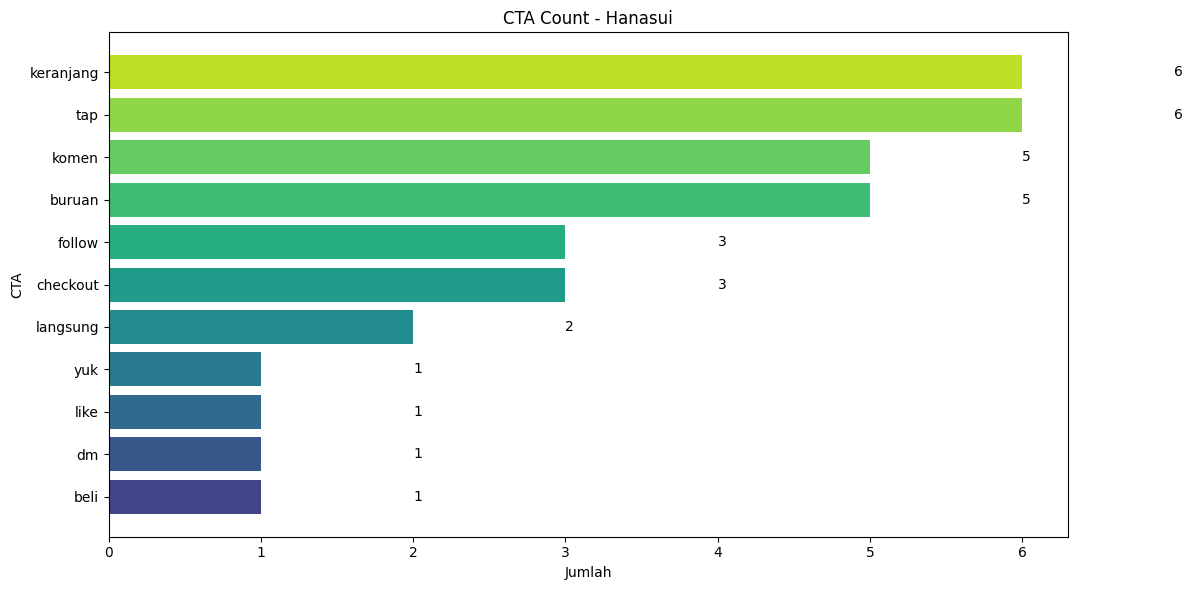

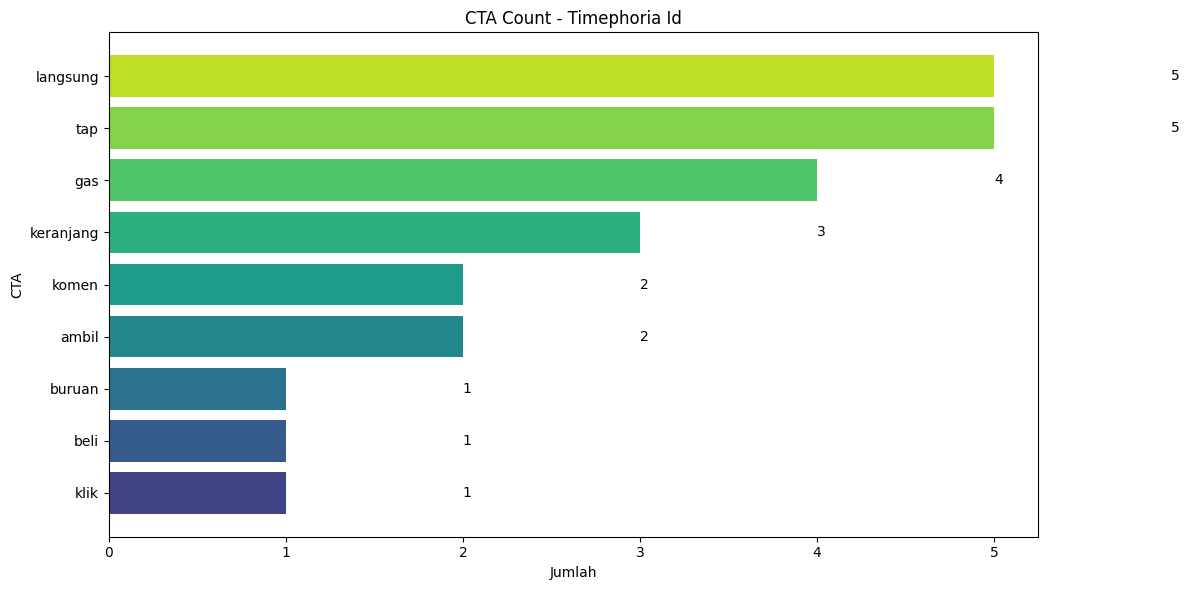

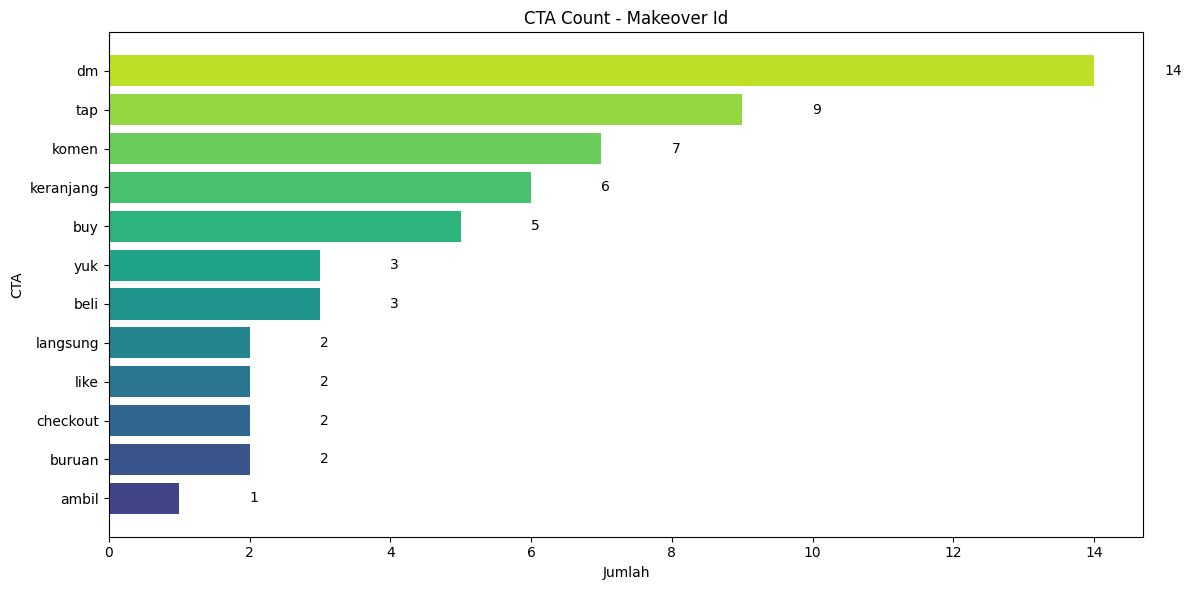

In [3]:
# =============================
# LIST CTA KEYWORDS
# =============================
cta_keywords = [
    "beli","checkout","check out","klik","keranjang",
    "komen","comment","tap","buruan","langsung",
    "gas","yuk","ambil","order","link","like",
    "dm","follow","share","pesan","grab","buy",
    "dapatkan"
]

# =============================
# CREATE BAR CHART PER BRAND
# =============================
brands = df["Brand"].dropna().unique()

for brand in brands:
    brand_data = df[df["Brand"] == brand]
    counter = Counter()

    for caption in brand_data["clean_caption"]:
        for cta in cta_keywords:
            if cta in caption:
                counter[cta] += 1

    if len(counter) == 0:
        continue

    table = (
        pd.DataFrame(counter.items(), columns=["CTA", "Jumlah"])
        .sort_values(by="Jumlah", ascending=True)
    )

    # =============================
    # PLOT
    # =============================
    plt.figure(figsize=(12, 6))
    
    # bikin gradasi warna
    colors = plt.cm.viridis(np.linspace(0.2, 0.9, len(table)))

    bars = plt.barh(table["CTA"], table["Jumlah"], color=colors)

    plt.title(f"CTA Count - {brand}")
    plt.xlabel("Jumlah")
    plt.ylabel("CTA")

    # =============================
    # LABEL ANGKA DI UJUNG BAR
    # =============================
    for bar in bars:
        width = bar.get_width()
        plt.text(width + 1, bar.get_y() + bar.get_height()/2,
                 str(int(width)),
                 va='center')

    plt.tight_layout()
    plt.show()